In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [2]:
df = pd.read_csv("../../raw/econ/fred_combined_daily_macro.csv")
df.head(10)

,Date,USD,OIL,GS10,GS10_MoM,GS10_YoY,GS2,GS2_MoM,GS2_YoY,GDP,...,FedFundsRate_YoY,Labor_Participation,Labor_Participation_MoM,Labor_Participation_YoY,Employment,Employment_MoM,Employment_YoY,Consumer_Confidence,Consumer_Confidence_MoM,Consumer_Confidence_YoY
0,2006-01-02,101.4155,NaN,4.42,NaN,NaN,4.4,NaN,NaN,13599.16,...,NaN,66.0,NaN,NaN,135427.0,NaN,NaN,91.2,NaN,NaN
1,2006-01-03,100.7558,63.11,4.42,NaN,NaN,4.4,NaN,NaN,13599.16,...,NaN,66.0,NaN,NaN,135427.0,NaN,NaN,91.2,NaN,NaN
2,2006-01-04,100.2288,63.41,4.42,NaN,NaN,4.4,NaN,NaN,13599.16,...,NaN,66.0,NaN,NaN,135427.0,NaN,NaN,91.2,NaN,NaN
3,2006-01-05,100.2992,62.81,4.42,NaN,NaN,4.4,NaN,NaN,13599.16,...,NaN,66.0,NaN,NaN,135427.0,NaN,NaN,91.2,NaN,NaN
4,2006-01-06,100.0241,64.21,4.42,NaN,NaN,4.4,NaN,NaN,13599.16,...,NaN,66.0,NaN,NaN,135427.0,NaN,NaN,91.2,NaN,NaN
5,2006-01-09,100.1794,63.56,4.42,NaN,NaN,4.4,NaN,NaN,13599.16,...,NaN,66.0,NaN,NaN,135427.0,NaN,NaN,91.2,NaN,NaN
6,2006-01-10,100.1436,63.41,4.42,NaN,NaN,4.4,NaN,NaN,13599.16,...,NaN,66.0,NaN,NaN,135427.0,NaN,NaN,91.2,NaN,NaN
7,2006-01-11,99.8710,63.91,4.42,NaN,NaN,4.4,NaN,NaN,13599.16,...,NaN,66.0,NaN,NaN,135427.0,NaN,NaN,91.2,NaN,NaN
8,2006-01-12,100.0643,63.96,4.42,NaN,NaN,4.4,NaN,NaN,13599.16,...,NaN,66.0,NaN,NaN,135427.0,NaN,NaN,91.2,NaN,NaN
9,2006-01-13,99.9675,63.86,4.42,NaN,NaN,4.4,NaN,NaN,13599.16,...,NaN,66.0,NaN,NaN,135427.0,NaN,NaN,91.2,NaN,NaN


In [10]:
print(df.info())
print(df.columns.unique())
print(df.dtypes.unique())

<class 'pandas.DataFrame'>
RangeIndex: 5256 entries, 0 to 5255
Data columns (total 36 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Date                     5256 non-null   str    
 1   USD                      5047 non-null   float64
 2   OIL                      5054 non-null   float64
 3   GS10                     5256 non-null   float64
 4   GS10_MoM                 5234 non-null   float64
 5   GS10_YoY                 4996 non-null   float64
 6   GS2                      5256 non-null   float64
 7   GS2_MoM                  5234 non-null   float64
 8   GS2_YoY                  4996 non-null   float64
 9   GDP                      1759 non-null   float64
 10  GDP_MoM                  1737 non-null   float64
 11  GDP_YoY                  1494 non-null   float64
 12  CPI                      5233 non-null   float64
 13  CPI_MoM                  5191 non-null   float64
 14  CPI_YoY                  4973 non-n

In [29]:
columns_we_wanna_remove = []
for i in df.columns:
    percentage_zero = round(sum(df[i].isnull()) / len(df[i]) * 100,2)
    # print(f"percentage where column {i} is empty: {percentage_zero}%")
    if percentage_zero > 5:
        columns_we_wanna_remove.append([i,percentage_zero])
        
        
        
print(f"the columns with a higher null rate {'are' if len(columns_we_wanna_remove) > 1 else 'is'} {columns_we_wanna_remove}")

the columns with a higher null rate are [['GDP', 66.53], ['GDP_MoM', 66.95], ['GDP_YoY', 71.58], ['CPI_YoY', 5.38], ['Unemployment_YoY', 5.38], ['Personal_Income_YoY', 5.67], ['Labor_Participation_YoY', 5.38]]


C:\Users\Luizv\AppData\Local\Temp\ipykernel_37540\1862249127.py:2: UserWarning: Tight layout not applied. tight_layout cannot make Axes width small enough to accommodate all Axes decorations
  plt.tight_layout()


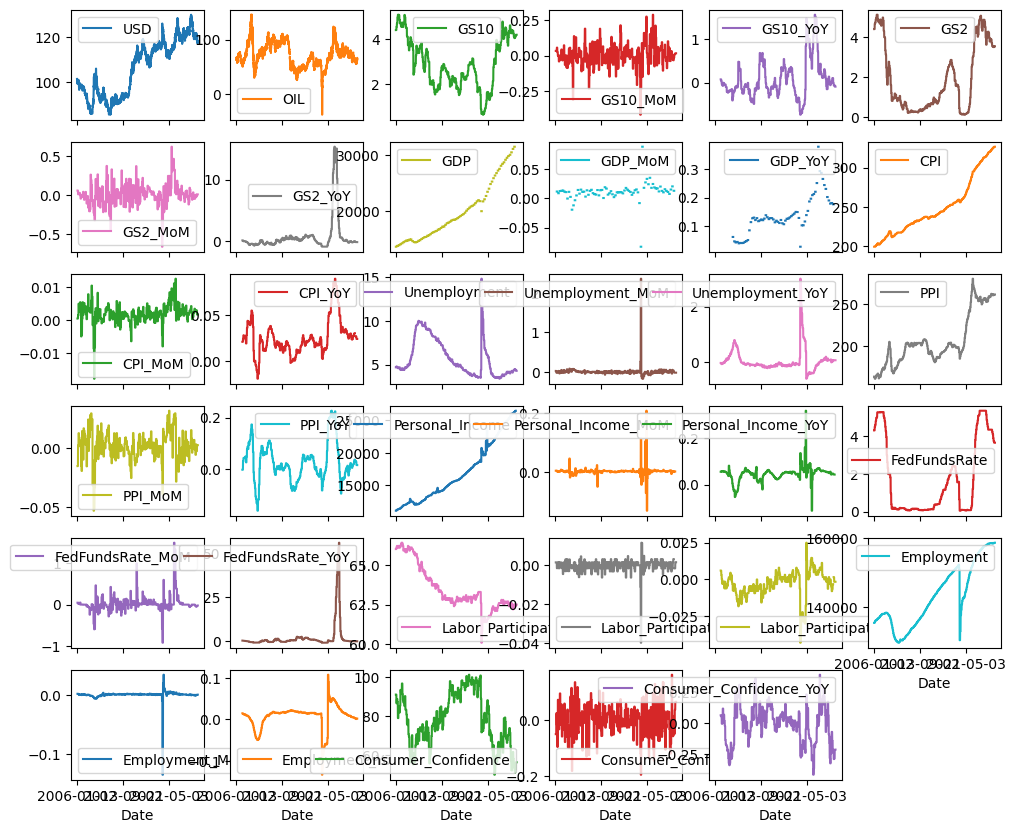

In [34]:
df.set_index("Date").plot(subplots=True, layout=(6, 6), figsize=(12, 10))
plt.tight_layout()
plt.show()

Voor ons model gaan we op de volgende dag voorspellen dus gaan we ook enkel de dagelijkse beschikbare data bijhouden.

YoY en MoM worden verwijderd uit de dataset

In [37]:
df_features = df[[col for col in df.columns if "MoM" not in col and "YoY" not in col]]
print(df_features.columns)

Index(['Date', 'USD', 'OIL', 'GS10', 'GS2', 'GDP', 'CPI', 'Unemployment',
       'PPI', 'Personal_Income', 'FedFundsRate', 'Labor_Participation',
       'Employment', 'Consumer_Confidence'],
      dtype='str')


In [73]:
for col in df_features.columns:
    n_missing = df_features[col].isna().sum()
    pct_missing = round(n_missing / len(df_features[col]) * 100, 2)
    print(f"{col}: {n_missing} missing ({pct_missing}%)")

Date: 0 missing (0.0%)
USD: 0 missing (0.0%)
OIL: 1 missing (0.02%)
GS10: 0 missing (0.0%)
GS2: 0 missing (0.0%)
GDP: 0 missing (0.0%)
CPI: 0 missing (0.0%)
Unemployment: 0 missing (0.0%)
PPI: 0 missing (0.0%)
Personal_Income: 0 missing (0.0%)
FedFundsRate: 0 missing (0.0%)
Labor_Participation: 0 missing (0.0%)
Employment: 0 missing (0.0%)
Consumer_Confidence: 0 missing (0.0%)


In [ ]:
# we vullen de gdp waardes op met de vorige gekende waardes totdat ze terug veranderd.
df_features = df_features.ffill()

In [63]:
df_features['GDP'].unique()

array([13599.16 , 13753.424, 13870.188, 14039.56 , 14215.651, 14402.082,
       14564.117, 14715.058, 14706.538, 14865.701, 14898.999, 14608.209,
       14430.902, 14381.236, 14448.882, 14651.249, 14764.61 , 14980.193,
       15141.607, 15309.474, 15351.448, 15557.539, 15647.68 , 15842.259,
       16068.805, 16207.115, 16319.541, 16420.419, 16648.189, 16728.687,
       16953.838, 17192.019, 17197.738, 17518.508, 17804.228, 17912.079,
       18063.529, 18279.784, 18401.626, 18435.137, 18525.933, 18711.702,
       18892.639, 19089.379, 19280.084, 19438.643, 19692.595, 20037.088,
       20328.553, 20580.912, 20798.73 , 20917.867, 21111.6  , 21397.938,
       21717.171, 21933.217, 21751.238, 19958.291, 21704.437, 22087.16 ,
       22680.693, 23425.91 , 23982.379, 24813.6  , 25250.347, 25861.292,
       26336.304, 26770.514, 27216.445, 27530.055, 28074.846, 28424.722,
       28708.161, 29147.044, 29511.664, 29825.182, 30042.113, 30485.729,
       31098.027, 31490.07 ])

In [66]:
df_features['OIL'].unique()

array([  nan, 63.11, 63.41, ..., 64.53, 64.2 , 64.8 ], shape=(3698,))

## Data Preperation

Voor ons LSTM model moeten we nu onze data gaan klaarzetten

In [ ]:
df_features['Date'] = pd.to_datetime(df_features['Date'])

In [45]:
df_features.size

73584

In [76]:
df_features.head(1)

,Date,USD,OIL,GS10,GS2,GDP,CPI,Unemployment,PPI,Personal_Income,FedFundsRate,Labor_Participation,Employment,Consumer_Confidence
0,2006-01-02,101.4155,63.11,4.42,4.4,13599.16,199.3,4.7,164.3,11038.6,4.29,66.0,135427.0,91.2


In [ ]:
# we vullen de eerste rij data OIL met de eerstvolgende data dat we tegenkomen
df_features['OIL'] = df_features['OIL'].bfill()

In [77]:
df_features.head(1)

,Date,USD,OIL,GS10,GS2,GDP,CPI,Unemployment,PPI,Personal_Income,FedFundsRate,Labor_Participation,Employment,Consumer_Confidence
0,2006-01-02,101.4155,63.11,4.42,4.4,13599.16,199.3,4.7,164.3,11038.6,4.29,66.0,135427.0,91.2


In [ ]:
df_features["yield_spread"] = df_features["GS10"] - df_features["GS2"]

1. De Normale Situatie (Positief getal)

In een gezonde economie is de spread positief (bijv. +1.5%).

    Logica: Als je geld voor 10 jaar uitleent, loop je meer risico (inflatie, onzekerheid) dan wanneer je het voor 2 jaar uitleent. Daarom eis je een hogere rente.

    Signaal: Beleggers zijn optimistisch over de toekomst. De economie groeit naar verwachting gestaag door.

2. De "Inverted Yield Curve" (Negatief getal)

Dit is het moment waarop de spread negatief wordt (bijv. -0.5%). Dit betekent dat de korte rente (GS2) hoger is dan de lange rente (GS10).

    Logica: Beleggers maken zich zorgen over de nabije toekomst. Ze "vluchten" in veilige 10-jaars obligaties, waardoor de rente daarop daalt, terwijl de centrale bank de korte rente vaak hoog houdt om inflatie te bestrijden.

    Signaal: Dit is historisch gezien de beste voorspeller voor een recessie. Bijna elke Amerikaanse recessie in de afgelopen 50 jaar werd voorafgegaan door een negatieve yield spread.

3. Waarom is dit goud waard voor je LSTM?

Een LSTM zoekt naar patronen die voorafgaan aan een grote beweging. De Yield Spread werkt vaak als een "vroege waarschuwing":

    Daling richting nul: De markt begint zenuwachtig te worden. Bull markets (stijgende koersen) worden vaak fragiel.

    Onder nul (Inversie): De kans op een beurscrash of een langdurige daling (bear market) binnen 6 tot 18 maanden neemt drastisch toe.

    "De-inversion": Als de spread na een lange tijd onder nul weer snel boven nul schiet, is dat vaak het teken dat de recessie nu echt begint en de centrale bank in paniek de rente verlaagt.

In [83]:
df_features['yield_spread'].unique()

array([ 0.02, -0.1 , -0.01,  0.1 ,  0.14, -0.01, -0.03, -0.02, -0.05,
       -0.07, -0.14, -0.11, -0.12, -0.13,  0.02, -0.02,  0.12,  0.18,
        0.36,  0.51,  0.56,  0.81,  0.98,  1.26,  1.77,  1.89,  1.63,
        1.43,  1.33,  1.44,  1.47,  1.61,  2.2 ,  2.32,  1.6 ,  1.71,
        1.89,  2.  ,  2.36,  2.54,  2.47,  2.44,  2.44,  2.6 ,  2.72,
        2.8 ,  2.83,  2.77,  2.79,  2.59,  2.48,  2.39,  2.18,  2.17,
        2.16,  2.31,  2.67,  2.78,  2.81,  2.71,  2.73,  2.61,  2.07,
        1.77,  1.87,  1.76,  1.72,  1.73,  1.69,  1.83,  1.51,  1.33,
        1.28,  1.41,  1.46,  1.47,  1.38,  1.64,  1.7 ,  1.53,  1.68,
        1.97,  2.24,  2.38,  2.41,  2.28,  2.42,  2.56,  2.38,  2.32,
        2.29,  2.15,  2.03,  1.95,  1.96,  1.85,  1.8 ,  1.57,  1.33,
        1.36,  1.4 ,  1.59,  1.67,  1.65,  1.19,  1.05,  1.01,  1.04,
        0.99,  0.91,  0.83,  0.82,  0.86,  0.92,  1.16,  1.29,  1.22,
        1.22,  1.17,  1.06,  1.  ,  0.85,  0.95,  0.87,  0.82,  0.81,
        0.65,  0.56,

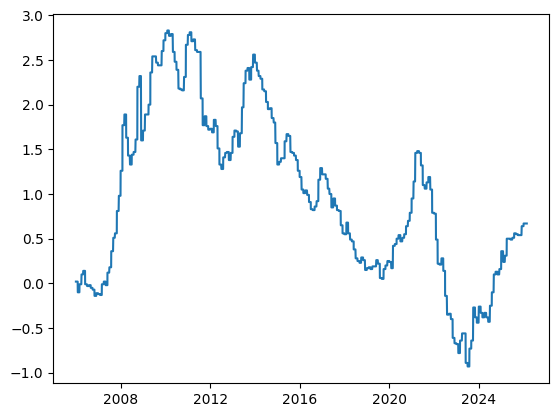

In [87]:
plt.plot(df_features['Date'], df_features['yield_spread'])

we kunnen zien dat vanaf de opkom van AI er een grote indicator is van een recessie (yield spread is < -0.5) dit is wat veel experten speculeren dat er gaat gebeuren omdat men denkt dat AI een bubbel is dat klaar staat om gebarsten te worden. Bedrijven zoals Nvidea, Apple, Microsoft,... die veel bijdragen aan de S&P 500 pompen zeer veel geld in AI om bij de race te kunnen blijven, ze maken deals met elkaar (curcular investing) om te kunnen blijven in de AI race maar dit gaat later voor problemen zorgen en sommige denken dat er dan een recessie gaat komen. Zonder AI was men al in een recessie geweest in 2022, dit kan je zien aan de grafiek cijfers maar ook verschillende artikelen die het zeggen.

**Sources (niet APA)**
* [circular investing and why it's a problem](https://builtin.com/articles/ai-circular-financing)
* [A top economist predicts a 'very significant' 2027 recession with 2 growth engines in peril](https://www.businessinsider.com/recession-stock-market-outlook-us-economy-fiscal-stimulus-ai-investment-2026-3)
* [JPMorgan](https://privatebank.jpmorgan.com/content/dam/jpm-pb-aem/global/en/documents/outlook2026/JPMorganOutlook2026PromiseandPressure.pdf#page=45)

Natuurlijk ook door de verschillende oorlogen en de onstabiele zekerheid van hoe het leven binnen 5 jaar eruit gaat zien heeft ook zijn impact op deze cijfers (**Speculatie van mezelf, niet backed!**)

Voor alle “price-like” features zoals USD en OIL:

In [88]:
df_features["USD_return"] = df_features["USD"].pct_change()
df_features["OIL_return"] = df_features["OIL"].pct_change()

7 en 30 daagse momentum:

In [89]:
df_features["USD_7d"] = df_features["USD"].pct_change(7)
df_features["USD_30d"] = df_features["USD"].pct_change(30)
df_features["OIL_7d"] = df_features["OIL"].pct_change(7)

Geeft het model info over schommelingen, niet alleen trend

In [90]:
df_features["USD_volatility"] = df_features["USD_return"].rolling(7).std()
df_features["OIL_volatility"] = df_features["OIL_return"].rolling(7).std()

Voor langzaam bewegende features zoals CPI, Unemployment:

In [91]:
df_features["CPI_change"] = df_features["CPI"].pct_change()
df_features["Unemployment_change"] = df_features["Unemployment"].diff()

In [92]:
df_features.columns

Index(['Date', 'USD', 'OIL', 'GS10', 'GS2', 'GDP', 'CPI', 'Unemployment',
       'PPI', 'Personal_Income', 'FedFundsRate', 'Labor_Participation',
       'Employment', 'Consumer_Confidence', 'yield_spread', 'USD_return',
       'OIL_return', 'USD_7d', 'USD_30d', 'OIL_7d', 'USD_volatility',
       'OIL_volatility', 'CPI_change', 'Unemployment_change'],
      dtype='str')

In [93]:
df_features.info()

<class 'pandas.DataFrame'>
RangeIndex: 5256 entries, 0 to 5255
Data columns (total 24 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   Date                 5256 non-null   datetime64[us]
 1   USD                  5256 non-null   float64       
 2   OIL                  5256 non-null   float64       
 3   GS10                 5256 non-null   float64       
 4   GS2                  5256 non-null   float64       
 5   GDP                  5256 non-null   float64       
 6   CPI                  5256 non-null   float64       
 7   Unemployment         5256 non-null   float64       
 8   PPI                  5256 non-null   float64       
 9   Personal_Income      5256 non-null   float64       
 10  FedFundsRate         5256 non-null   float64       
 11  Labor_Participation  5256 non-null   float64       
 12  Employment           5256 non-null   float64       
 13  Consumer_Confidence  5256 non-null   float64

In [94]:
df_features.head(10)

,Date,USD,OIL,GS10,GS2,GDP,CPI,Unemployment,PPI,Personal_Income,...,yield_spread,USD_return,OIL_return,USD_7d,USD_30d,OIL_7d,USD_volatility,OIL_volatility,CPI_change,Unemployment_change
0,2006-01-02,101.4155,63.11,4.42,4.4,13599.16,199.3,4.7,164.3,11038.6,...,0.02,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2006-01-03,100.7558,63.11,4.42,4.4,13599.16,199.3,4.7,164.3,11038.6,...,0.02,-0.006505,0.000000,NaN,NaN,NaN,NaN,NaN,0.0,0.0
2,2006-01-04,100.2288,63.41,4.42,4.4,13599.16,199.3,4.7,164.3,11038.6,...,0.02,-0.005230,0.004754,NaN,NaN,NaN,NaN,NaN,0.0,0.0
3,2006-01-05,100.2992,62.81,4.42,4.4,13599.16,199.3,4.7,164.3,11038.6,...,0.02,0.000702,-0.009462,NaN,NaN,NaN,NaN,NaN,0.0,0.0
4,2006-01-06,100.0241,64.21,4.42,4.4,13599.16,199.3,4.7,164.3,11038.6,...,0.02,-0.002743,0.022289,NaN,NaN,NaN,NaN,NaN,0.0,0.0
5,2006-01-09,100.1794,63.56,4.42,4.4,13599.16,199.3,4.7,164.3,11038.6,...,0.02,0.001553,-0.010123,NaN,NaN,NaN,NaN,NaN,0.0,0.0
6,2006-01-10,100.1436,63.41,4.42,4.4,13599.16,199.3,4.7,164.3,11038.6,...,0.02,-0.000357,-0.002360,NaN,NaN,NaN,NaN,NaN,0.0,0.0
7,2006-01-11,99.8710,63.91,4.42,4.4,13599.16,199.3,4.7,164.3,11038.6,...,0.02,-0.002722,0.007885,-0.015229,NaN,0.012676,0.003005,0.011218,0.0,0.0
8,2006-01-12,100.0643,63.96,4.42,4.4,13599.16,199.3,4.7,164.3,11038.6,...,0.02,0.001935,0.000782,-0.006863,NaN,0.013469,0.002656,0.011201,0.0,0.0
9,2006-01-13,99.9675,63.86,4.42,4.4,13599.16,199.3,4.7,164.3,11038.6,...,0.02,-0.000967,-0.001563,-0.002607,NaN,0.007097,0.001901,0.011193,0.0,0.0


In [100]:
df_features.to_csv("../../processed/econ/econ_processed.csv", index=False)

## Standardizen

In [107]:
from sklearn.preprocessing import MinMaxScaler

features = df_features.drop(columns="Date")
scaler = MinMaxScaler()
scaled_features = scaler.fit_transform(features)